### Load basic libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.datasets import make_moons

In [30]:
x,y=make_moons(n_samples=300,noise=0.20)

In [31]:
x.size

600

In [32]:
y.size

300

In [33]:
data=pd.DataFrame(x,columns=["Feature 1","Feature2"])

In [34]:
data

,Feature 1,Feature2
0,1.465988,-0.198228
1,0.520630,-0.506908
2,0.100578,0.791709
3,0.896396,0.455665
4,-0.270908,0.896518
...,...,...
295,0.315260,0.233915
296,0.261324,0.898935
297,-0.460708,0.512352
298,1.735510,-0.436392


<Axes: xlabel='Feature 1', ylabel='Feature2'>

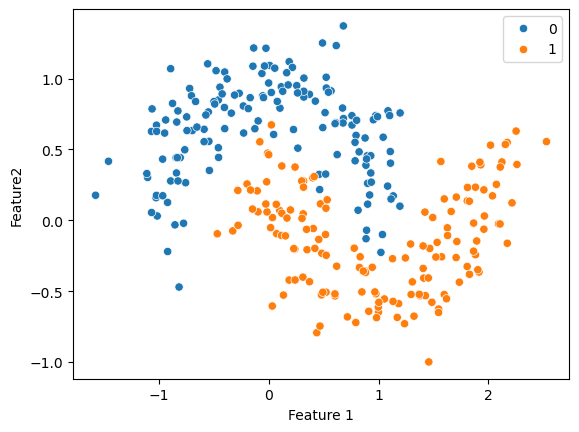

In [35]:
sns.scatterplot(data=data,x=data["Feature 1"],y=data["Feature2"],hue=y)

### Data Splition

In [36]:
from sklearn.model_selection import train_test_split

In [37]:
x_train,x_test,y_train,y_test=train_test_split(data,y,test_size=0.30,random_state=42)

In [39]:
x_train.head()

,Feature 1,Feature2
194,0.301504,0.013933
101,0.070831,-0.094441
68,1.052127,-0.554777
224,-0.017315,0.059107
37,-0.199174,0.256430


In [42]:
y_train.size

210

### Modeling Builing part

In [43]:
from sklearn.neighbors import KNeighborsClassifier

In [44]:
model=KNeighborsClassifier(n_neighbors=5)

In [45]:
model.fit(x_train,y_train)    

KNeighborsClassifier()

In [46]:
y_pred=model.predict(x_test)

In [51]:
from sklearn.metrics import accuracy_score,confusion_matrix

In [48]:
accuracy_score(y_test,y_pred)

0.9777777777777777

In [52]:
print(confusion_matrix(y_test,y_pred))

[[36  2]
 [ 0 52]]


### Let's find best value for K

In [54]:
from sklearn.model_selection import cross_val_score

In [69]:
k_range=range(1,20)
cross_val=[]
for k in k_range:
    knn=KNeighborsClassifier(n_neighbors=k)
    score=cross_val_score(knn,x_train,y_train,cv=5,scoring="accuracy")
    cross_val.append(score.mean())

In [70]:
cross_val

[0.9523809523809523,
 0.9523809523809522,
 0.9571428571428571,
 0.9523809523809523,
 0.9666666666666668,
 0.961904761904762,
 0.961904761904762,
 0.9761904761904763,
 0.9761904761904763,
 0.9761904761904763,
 0.980952380952381,
 0.980952380952381,
 0.9761904761904763,
 0.9761904761904763,
 0.9714285714285715,
 0.9666666666666668,
 0.9666666666666668,
 0.9666666666666668,
 0.9714285714285715]

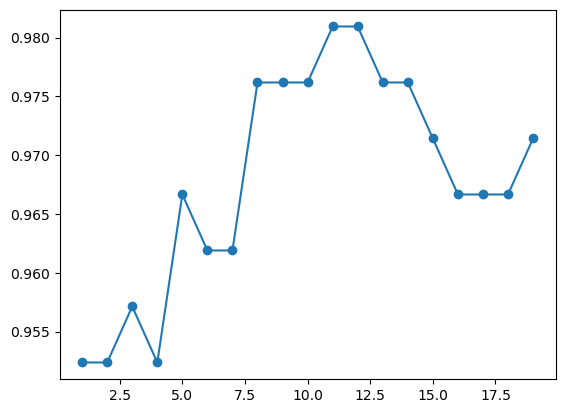

In [71]:
plt.plot(k_range,cross_val,marker="o")
plt.show()

In [72]:
model1=KNeighborsClassifier(n_neighbors=11)
model1.fit(x_train,y_train)    
y_pred=model1.predict(x_test)
accuracy_score(y_test,y_pred)

0.9777777777777777